## intro 

In [1]:
import pandas as pd
import numpy as np 
from itertools import combinations, chain
from tqdm import tqdm
from multiprocessing import Pool
import os
from glob import glob

In [2]:
old_path = os.getcwd()
new_path = old_path + '/../../'
os.chdir(new_path)
current_path = os.getcwd()
data_raw_path = current_path + '/data/raw/'
data_processed_path = current_path + '/data/processed/'

## functions 

In [3]:
def is_non_zero_file(fpath):  
    return True if os.path.isfile(fpath) and os.path.getsize(fpath) > 0 else False

def FloatToStr(series_to_transform: pd.Series) -> pd.Series:
    series_to_transform = series_to_transform.astype('Int64').astype(str)
    series_to_transform[series_to_transform == '<NA>'] = np.nan
    return(series_to_transform)

def filter_genes(l_input: tuple) -> pd.DataFrame:
    l_gene, l_subset = l_input
    # filtering out duplicated gene symbols based on the existence of corresponding HGNC ID
    if len(l_subset['ENSG_ID'].unique()) > 1:
        l_subset = l_subset[~l_subset['HGNC_ID'].isna()]
    # filtering out duplicated gene symbols based on the existence of corresponding EntrezGene ID
    if len(l_subset['ENSG_ID'].unique()) > 1:
        l_subset = l_subset[~l_subset['NCBI_ID'].isna()]
    # filtering out duplicated gene symbols based on the existence of corresponding UniProt ID
    if len(l_subset['ENSG_ID'].unique()) > 1: 
        l_subset = l_subset[~l_subset['UniProt_ID'].isna()]
    # 
    if len(l_subset['NCBI_ID'].unique()) > 1:
        l_genes_bad_ncbi = human_genes_raw[human_genes_raw['NCBI_ID'].isin(l_subset['NCBI_ID'].unique())]
        l_other_genes = l_genes_bad_ncbi[l_genes_bad_ncbi['GeneName'] != l_gene]
        if len(l_other_genes['NCBI_ID'].unique()) == 1:
            l_subset = l_subset[l_subset['NCBI_ID'] != l_other_genes['NCBI_ID'].unique()[0]]
    if len(l_subset['NCBI_ID'].unique()) > 1:
        l_hgnc = hgnc_biomart_genes[hgnc_biomart_genes['ENSG_ID'] == l_subset['ENSG_ID'].unique()[0]]
        if len(l_hgnc) >= 1:
            l_subset = l_subset[l_subset['NCBI_ID'] == l_hgnc['NCBI_ID'].unique()[0]]
    l_subset = l_subset.drop_duplicates(subset = ['ENSG_ID', 'GeneName', 'GeneSynonym'])
    return(l_subset)

def parse_gene_file() -> pd.DataFrame:
    global human_genes
    global human_genes_raw
    global human_genes_unique
    global hgnc_biomart_genes
    # Load HGNC biomart data, for filtering purposes, this file had been previously downloaded using the BIOMART tool from ensembl.org
    hgnc_biomart_genes = pd.read_csv(
        filepath_or_buffer = data_raw_path + 'HGNC_biomart_20221118.txt', 
        sep = '\t', 
        header = 0
    )
    hgnc_biomart_genes.columns = [
        'HGNC_ID', 'Status', 'Approved_symbol', 'Approved_name', 'Previous_symbol', 'Alias_symbol', 
        'Previous_name', 'HGNC_family ID', 'HGNC_family_name', 'Alias_name', 'ENSG_ID', 'NCBI_ID','UCSC_ID', 'RefSeq_ID', 'UniProt_ID', 'OMIM_ID'
        ]
    hgnc_biomart_genes.NCBI_ID = FloatToStr(hgnc_biomart_genes['NCBI_ID'])

    if is_non_zero_file(data_processed_path + 'human_genes_20230221.tsv'): 
        human_genes = pd.read_csv(
            filepath_or_buffer = data_processed_path + 'human_genes_20230221.tsv', 
            sep = '\t',
            header = 0,
            dtype = str,
            na_values = 'NaN'
            )
        human_genes_unique = human_genes.get(['ENSG_ID', 'GeneName']).drop_duplicates()
        human_genes_unique = human_genes_unique.reset_index(drop=True)
    else:
        from pybiomart import Dataset
        # get ALL ensembl data from biomart and filter after
        # I had downloaded this file in 2023, February the 21st (20230221)
        # in a future version, I will use an updated version of ensembl
        print('Loading from biomart can take some time, please do not cancel')
        dataset = Dataset(name='hsapiens_gene_ensembl', host='http://www.ensembl.org')

        ensembl_all = dataset.query(
            attributes = ['ensembl_gene_id', 'external_gene_name', 'external_synonym', 'chromosome_name', 
                'gene_biotype', 'entrezgene_id', 'hgnc_id', 'uniprot_gn_id', 'ensembl_peptide_id', 'transcript_mane_select']
        )
        ensembl_all.columns = ["ENSG_ID", "GeneName", "GeneSynonym", "chr", "GeneType", "NCBI_ID", "HGNC_ID", "UniProt_ID", "ENSP_ID", "RefSeq_MANE_ID"]

        ensembl_all['NCBI_ID'] = FloatToStr(ensembl_all['NCBI_ID'])
        ensembl_all.to_csv('data/raw/ensembl_all_20230221.tsv', 
                           sep = "\t", 
                           na_rep = "NaN",
                           header = True, 
                           index = False,
                           mode = 'w')
        chr_list = [str(x) for x in np.arange(1, 23)] + ["X", "Y"]
        # get all the non protein coding genes (npc) and those NOT on reference assembly. Can be useful to filter
        npc = ensembl_all[ensembl_all.GeneType != "protein_coding"]
        npc = pd.concat([npc, ensembl_all[~ensembl_all.chr.isin(chr_list)]], axis = 0)
        npc = npc.reset_index(drop = True)
        npc.to_csv(data_processed_path+'non_protein_coding_genes_20230221.tsv',
                   sep = "\t", 
                   na_rep = "NaN",
                   header = 0,
                   index = False,
                   mode = 'w')
        human_genes_raw = ensembl_all[ensembl_all.chr.isin(chr_list)]
        human_genes_raw = human_genes_raw[human_genes_raw.GeneType == 'protein_coding']
        # If you get a "Query Error" from the previous line, delete the pybiomart.sqlite file and retry
        human_genes_raw = human_genes_raw[~human_genes_raw.GeneName.isna()]
        human_genes_raw = human_genes_raw.reset_index(drop = True)
        parsed_genes = []
        with Pool(processes = 6) as pool:
            for l_gene in pool.imap(filter_genes, human_genes_raw.groupby("GeneName")):
                parsed_genes.append(l_gene)
        human_genes = pd.concat(parsed_genes, axis = 0, ignore_index = True, sort = False)
        # keep HGNC_ID in human_genes.columns
        human_genes = human_genes[['ENSG_ID', 'HGNC_ID', 'GeneName', 'GeneSynonym', 'NCBI_ID']]
        # there is a trouble for TBCE and HERC3 and NOX5: they each have 2 ENSG_ID, but only one HGNC_ID
        trouble_genes_dict = {'TBCE': 'ENSG00000284770', 'HERC3': 'ENSG00000138641', 'NOX5': 'ENSG00000255346'}
        for genename in trouble_genes_dict.keys():
            human_genes.loc[human_genes[human_genes.GeneName == genename].index, 'ENSG_ID'] = trouble_genes_dict[genename]
        human_genes = human_genes.drop_duplicates()
        human_genes = human_genes.reset_index(drop=True)
        human_genes.to_csv(
            path_or_buf = "data/processed/human_genes_20230221.tsv",
            sep = "\t",
            na_rep = "NaN",
            header = True,
            index = False,
            mode = 'w')
        human_genes_unique = human_genes.get(['ENSG_ID', 'GeneName']).drop_duplicates()
        human_genes_unique = human_genes_unique.reset_index(drop=True)
    return(human_genes, human_genes_unique)

def ENSG_to_GeneName(human_genes_unique: pd.DataFrame, series_to_match: pd.Series) -> pd.Series:
    merging_id = series_to_match.name
    input_len = len(series_to_match)
    series_to_match = pd.DataFrame({merging_id : series_to_match.values, "l_index": series_to_match.index.values})
    series_to_match = pd.merge(series_to_match, human_genes_unique.get(['ENSG_ID', 'GeneName']), how = 'left', left_on = merging_id, right_on = 'ENSG_ID')
    output_len = len(series_to_match)
    if (input_len - output_len) != 0:
        raise ValueError('')
    return(series_to_match.GeneName)

def gene_name_to_ENSG(human_genes: pd.DataFrame, series_to_match: pd.Series) -> pd.Series:
    merging_id = series_to_match.name
    series_to_match = pd.DataFrame({merging_id : series_to_match.values, 'l_index': series_to_match.index.values})
    series_to_match = pd.merge(
        series_to_match, 
        human_genes.drop_duplicates(subset=['ENSG_ID', 'GeneName']).loc[:,['ENSG_ID', 'GeneName']], 
        how = 'left', 
        left_on = merging_id, 
        right_on = 'GeneName'
    )
    series_to_match = series_to_match.drop('GeneName', axis = 1)
    # Check for missing ENSG. If any, try with gene name synonyms
    # beware, some genesynonym can correspond to different ENSG_ID: in doubt, remove them
    series_to_match_missing = series_to_match.iloc[series_to_match[series_to_match['ENSG_ID'].isna()].index]
    missing_list = series_to_match_missing[merging_id].unique().tolist()
    to_remove_list = []
    tmp = human_genes.drop_duplicates(subset=['ENSG_ID', 'GeneSynonym']).loc[:,['ENSG_ID', 'GeneSynonym']]
    for i in missing_list:
        if len(tmp[tmp['GeneSynonym'] == i]) > 1: # there are several ENSG_ID for each GeneSynonym = troubles
            missing_list.remove(i)
            to_remove_list.append(i)
        else:
            pass # only one ENSG_ID for each GeneSynonym
    if len(to_remove_list) >= 1:
        print(f'There are {len(to_remove_list)} genes whose GeneSynonym is associated to >1 ENSG_ID in human_genes file, they will need to be removed.')
    # these GeneSynonyms are linked to several ENSG_ID = I need to remove them later
    series_to_match_to_remove = series_to_match_missing[series_to_match_missing[merging_id].isin(to_remove_list)]
    series_to_match_missing = series_to_match_missing.drop(series_to_match_missing[series_to_match_missing[merging_id].isin(to_remove_list)].index, axis=0)
    if len(series_to_match_missing) != 0:
        series_to_match_missing = series_to_match_missing.drop("ENSG_ID", axis = 1)
        series_to_match_missing = pd.merge(
            series_to_match_missing, 
            human_genes.drop_duplicates(subset=['ENSG_ID', 'GeneSynonym']).loc[:,['ENSG_ID', 'GeneSynonym']], 
            how = 'left', 
            left_on = merging_id, 
            right_on = 'GeneSynonym'
        )
        series_to_match_missing = series_to_match_missing.drop('GeneSynonym', axis = 1)
        series_to_match_ok = series_to_match.iloc[series_to_match[~series_to_match['ENSG_ID'].isna()].index]
        series_to_match = pd.concat(
            [series_to_match_ok, 
             series_to_match_missing[[merging_id, 'ENSG_ID', 'l_index']],
             series_to_match_to_remove[[merging_id, 'ENSG_ID', 'l_index']]],
            ignore_index = True, 
            sort = False
        )
        series_to_match = series_to_match.sort_values(by = 'l_index', axis = 0, ascending = True)
        series_to_match = series_to_match.reset_index(drop=True)
        series_to_match.loc[series_to_match[series_to_match.duplicated(subset='l_index', keep=False)].index, 'ENSG_ID'] = np.nan
        series_to_match = series_to_match.drop(series_to_match.index[series_to_match.duplicated(subset='l_index')])
        series_to_match = series_to_match.reset_index(drop=True)
    return series_to_match['ENSG_ID'].values 

def NCBI_to_ENSG(human_genes: pd.DataFrame, series_to_match: pd.Series) -> pd.Series:
    merging_id = series_to_match.name
    series_length = len(series_to_match)
    series_to_match = pd.DataFrame({merging_id : series_to_match.values, "l_index": series_to_match.index.values})
    series_to_match = pd.merge(
        series_to_match, 
        human_genes.drop_duplicates(subset=["ENSG_ID", "GeneName"]).loc[:,["ENSG_ID", "NCBI_ID"]], 
        how = 'left', 
        left_on = merging_id, 
        right_on = 'NCBI_ID'
    )
    if (series_length != series_to_match.l_index.value_counts().values.sum()):
        series_to_match_duplicated = series_to_match[series_to_match.duplicated(subset='l_index', keep=False)]
        for l_gene in series_to_match_duplicated[merging_id].unique():
            l_subset = series_to_match_duplicated[series_to_match_duplicated[merging_id] == l_gene]
            # l_subset["ENSG_ID"] = hgnc_biomart_genes[hgnc_biomart_genes.NCBI_ID == l_gene] Removed as seems useless on later runs...
            series_to_match.loc[l_subset.index[l_subset[merging_id] == l_gene], "ENSG_ID"] = hgnc_biomart_genes[hgnc_biomart_genes.NCBI_ID == l_gene]["ENSG_ID"].values[0]
    series_to_match.drop_duplicates(subset = "l_index", keep = 'first', inplace = True)
    series_to_match = series_to_match.sort_values(by = "l_index", axis = 0, ascending = True)
    return(series_to_match['ENSG_ID'].values)

def create_nop(df: pd.DataFrame, same_node_type: bool = True) -> pd.DataFrame:
    if same_node_type:
        df['names_are_ordered'] = df['node1_ID'] < df['node2_ID']
        ordered_index = df[df['names_are_ordered'] == True].index
        reverse_ordered_index = df[df['names_are_ordered'] == False].index
        # create the names for the pairs 
        df.loc[ordered_index, 'name_of_pair'] = df['node1_ID'].astype(str) + '_' + df['node2_ID'].astype(str)
        df.loc[reverse_ordered_index, 'name_of_pair'] = df['node2_ID'].astype(str) + '_' + df['node1_ID'].astype(str) 
    else:
        df.loc[:, 'name_of_pair'] = df['node1_ID'].astype(str) + '_' + df['node2_ID'].astype(str)
    return df

In [4]:
human_genes, human_genes_unique = parse_gene_file()

In [5]:
human_genes_unique

,ENSG_ID,GeneName
0,ENSG00000121410,A1BG
1,ENSG00000148584,A1CF
2,ENSG00000175899,A2M
3,ENSG00000166535,A2ML1
4,ENSG00000184389,A3GALT2
...,...,...
19389,ENSG00000203995,ZYG11A
19390,ENSG00000162378,ZYG11B
19391,ENSG00000159840,ZYX
19392,ENSG00000074755,ZZEF1


## open net df

In [50]:
string_threshold = -1

# open the Human_Knowledge_Graph
net = pd.read_csv(data_processed_path + f'human_knowledge_graph.tsv', sep = '\t', header = 0, dtype = {0: str, 1: str, 3: str, 4: str})
net = net.drop(net[(net['EdgeType'].isin(['PPI'])) & (net['EdgeScore'] < string_threshold)].index, axis = 0)
net = net.reset_index(drop = True)
# I will not be using these edges,maybe in a future version ? 
# edges_to_remove = [
#     'CoExp', 'Neighbour', 
#     'not_expressed_in', 'DIDA',
#     'synthetic_lethal', 'synthetic_non_lethal', 
#     'regulatory_proximal', 'regulatory_distal'
#     ]
# net = net.drop(net[net['EdgeType'].isin(edges_to_remove)].index, axis=0)
# net = net.reset_index(drop=True)

all_genes = list(set().union(net[net['node1_type'] == 'GENE']['node1_ID'].unique(), net[net['node2_type'] == 'GENE']['node2_ID'].unique()))
# I could hardcode edges_names, edge_summary eveneutally
edges_names = net['EdgeType'].value_counts().to_dict()
edges_summary = []
for edge_name in edges_names.keys():
    tmp_list = [edge_name, 
                net[net['EdgeType'] == edge_name]['node1_type'].unique()[0], 
                net[net['EdgeType'] == edge_name]['node2_type'].unique()[0], 
                net[net['EdgeType'] == edge_name]['EdgeDirection'].unique()[0], 
                edges_names[edge_name]]
    # create a special case when there are edge_attributes
    # not currently using edges_attributes, but maybe in a future version 
    if sum(net[net['EdgeType'] == edge_name]['EdgeScore'].isna()) == 0:
        tmp_list.append(1)
    else:
        tmp_list.append(0)
    edges_summary.append(tmp_list) 

edges_types = list(set(net['EdgeType'].unique()))
nodes_types = list(set().union(net['node1_type'].unique(),net['node2_type'].unique()))
nodes_types.sort()
nodes_numbers = {}
for node_type in nodes_types:
    nodes_numbers[node_type] = len(set().union(net[net['node1_type'] == node_type]['node1_ID'].unique(), net[net['node2_type'] == node_type]['node2_ID'].unique()))

print(f"nodes_types: {nodes_types}")
print(f"nodes_numbers: {nodes_numbers}")

list_of_edges = net['EdgeType'].unique().tolist()

def Get_df_for_nodetype_id(df: pd.DataFrame, node_type : str) -> pd.DataFrame:
    node_type_list = list(set().union(df[df['node1_type'] == node_type]['node1_ID'].unique(), df[df['node2_type'] == node_type]['node2_ID'].unique()))
    node_type_list.sort()
    node_type_array = np.asarray(node_type_list)
    new_df = pd.DataFrame(data = {
        f"{node_type}_id": node_type_array,
        "mapped_id": pd.RangeIndex(len(node_type_array))
    })
    return(new_df)

nodes2id = {}
for type_of_node in nodes_types:
    nodes2id[type_of_node] = Get_df_for_nodetype_id(net, type_of_node)

nodes_types: ['ANATOMY', 'BP', 'CC', 'GENE', 'MF']
nodes_numbers: {'ANATOMY': 14337, 'BP': 27993, 'CC': 4039, 'GENE': 19491, 'MF': 11271}


In [51]:
nodes = nodes2id['GENE'].copy()
genes = nodes['GENE_id'].tolist()

## Synlethdb 20240301

In [ ]:
# download data from synlethdb
# https://www.synlethdb.com/download/

In [32]:
df = pd.read_csv(
        data_raw_path + "synlethdb_Human_SL_20240301.csv",
        sep=",",
        header=0
    )

In [33]:
df.columns = ['node1_name', 'node1_identifier', 'node2_name', 'node2_identifier', 'cell', 'pubmed', 'source', 'score']
df['EdgeType'] = 'SL'
df['node1_identifier'] = df['node1_identifier'].astype(str)
df['node2_identifier'] = df['node2_identifier'].astype(str)

In [34]:
df["node1_ID"] = NCBI_to_ENSG(human_genes, df["node1_identifier"])
df["node2_ID"] = NCBI_to_ENSG(human_genes, df["node2_identifier"])

In [35]:
df

,node1_name,node1_identifier,node2_name,node2_identifier,cell,pubmed,source,score,EdgeType,node1_ID,node2_ID
0,TMEM35A,59353,PTEN,5728,NaN,26427375,Computational Prediction,0.300,SL,ENSG00000126950,ENSG00000171862
1,TMEM35A,59353,BRCA2,675,NaN,26427375,Computational Prediction,0.300,SL,ENSG00000126950,ENSG00000139618
2,CIDEA,1149,NAE1,8883,A375,23100467,GenomeRNAi,0.500,SL,ENSG00000176194,ENSG00000159593
3,FHL5,9457,OPRK1,4986,NaN,25171417,Computational Prediction,0.300,SL,ENSG00000112214,ENSG00000082556
4,FHL5,9457,GHRHR,2692,NaN,25171417,Computational Prediction,0.300,SL,ENSG00000112214,ENSG00000106128
...,...,...,...,...,...,...,...,...,...,...,...
35938,PRKCQ,5588,SLC22A1,6580,K562;K562,20609354,GenomeRNAi,0.521,SL,ENSG00000065675,ENSG00000175003
35939,RNF19A,25897,TP53,7157,NaN,26427375,Computational Prediction,0.300,SL,ENSG00000034677,ENSG00000141510
35940,SLC10A7,84068,ATM,472,NaN,26427375,Computational Prediction,0.300,SL,ENSG00000120519,ENSG00000149311
35941,SVIL,6840,PTEN,5728,NaN,26427375,Computational Prediction,0.300,SL,ENSG00000197321,ENSG00000171862


In [36]:
missing = []
missing += df[df['node1_ID'].isna()]['node1_name'].unique().tolist()
missing += df[df['node2_ID'].isna()]['node2_name'].unique().tolist()
missing = list(set(missing))
missing.sort()

In [37]:
missing

['ADGRF2',
 'C17orf77',
 'C19orf48',
 'C1orf229',
 'C3orf35',
 'CCL3L1',
 'CLECL1',
 'DNAJB3',
 'GAGE12I',
 'GAGE2C',
 'LOC101928841',
 'LOC284898',
 'LOC643802',
 'MICOS10-NBL1',
 'MIR1-1HG',
 'NAT8B',
 'ND4',
 'OFCC1',
 'SLC66A1L',
 'TRIM16L',
 'VN1R5',
 'XKRY',
 'ZNF705E']

--------------------------------------------------------------------------------------------------------
* ADGRF2: mouse gene
* ADGRF2P: pseudogene in humans 
* https://www.genenames.org/tools/search/#!/?query=adgrf2
* https://www.ensembl.org/Homo_sapiens/Gene/Summary?db=core;g=ENSG00000164393;r=6:47673420-47693719;t=ENST00000507065
* 'ADGRF2P': 'ENSG00000164393'
--------------------------------------------------------------------------------------------------------
* C17orf77 = CD300LD-AS1 
* antisense RNA 
* https://www.genenames.org/data/gene-symbol-report/#!/hgnc_id/HGNC:26480
* https://www.ensembl.org/Homo_sapiens/Gene/Summary?db=core;g=ENSG00000291923;r=HG2580_PATCH:161127-170657
--------------------------------------------------------------------------------------------------------
* C19orf48 = C19orf48P
* pseudogene
* https://www.genenames.org/data/gene-symbol-report/#!/hgnc_id/HGNC:29667
* https://www.ensembl.org/Homo_sapiens/Gene/Summary?db=core;g=ENSG00000293495;r=19:50797687-50804931
--------------------------------------------------------------------------------------------------------
* C1orf229 = LINC02897 
* long intergenic non-protein coding RNA 2897
* lncRNA
* https://www.genenames.org/data/gene-symbol-report/#!/hgnc_id/HGNC:33759
* https://www.ensembl.org/Homo_sapiens/Gene/Summary?db=core;g=ENSG00000221953;r=1:247108335-247112417
--------------------------------------------------------------------------------------------------------
* C3orf35 = APRG1
* lncRNA
* https://www.genenames.org/data/gene-symbol-report/#!/hgnc_id/HGNC:24082
* https://www.ensembl.org/Homo_sapiens/Gene/Summary?db=core;g=ENSG00000198590;r=3:37381062-37440186
--------------------------------------------------------------------------------------------------------
* CCL3L1 = CCL3L3
* NCBI = 6349 ou 414062
* https://www.genenames.org/data/gene-symbol-report/#!/hgnc_id/HGNC:10628
* https://www.genenames.org/data/gene-symbol-report/#!/hgnc_id/HGNC:30554
* https://www.ensembl.org/Homo_sapiens/Gene/Summary?db=core;g=ENSG00000277768;r=HSCHR17_10_CTG4:250577-252466;t=ENST00000615140
--------------------------------------------------------------------------------------------------------
* CLECL1 = CLECL1P
* pseudogene
* transcribed unitary pseudogene 
* https://www.genenames.org/data/gene-symbol-report/#!/hgnc_id/HGNC:24462
* https://www.ensembl.org/Homo_sapiens/Gene/Summary?db=core;g=ENSG00000184293;r=12:9722644-9733030;t=ENST00000621400
--------------------------------------------------------------------------------------------------------
* DNAJB3
* transcribed processed pseudogene
* https://www.genenames.org/data/gene-symbol-report/#!/hgnc_id/HGNC:32397
* https://www.ensembl.org/Homo_sapiens/Gene/Summary?db=core;g=ENSG00000227802;r=2:233743188-233743916;t=ENST00000446806
--------------------------------------------------------------------------------------------------------
* GAGE12I = GAGE12G
* https://www.genecards.org/cgi-bin/carddisp.pl?gene=GAGE12G&keywords=GAGE12G
* NCBI: 26748
* https://www.genenames.org/data/gene-symbol-report/#!/hgnc_id/HGNC:4105
* https://www.ensembl.org/Homo_sapiens/Gene/Summary?db=core;g=ENSG00000215269;r=X:49570400-49577754;t=ENST00000445148
--------------------------------------------------------------------------------------------------------
* GAGE2C = GAGE12F
* https://www.genenames.org/data/gene-symbol-report/#!/hgnc_id/HGNC:31958
* https://www.ensembl.org/Homo_sapiens/Gene/Summary?db=core;g=ENSG00000236362;r=X:49551278-49568218
* raw = pd.read_csv('/data-cbl/rnicolle/GRL4DD/data/raw/human_ensembl_pheno_20250221.tsv', header = 0, sep = '\t', dtype = {8: str})
* raw[raw['NCBI gene (formerly Entrezgene) ID'] == 2574]
* 'GAGE2C': 'ENSG00000236362'
* 2574: 'ENSG00000236362'
--------------------------------------------------------------------------------------------------------

* LOC101928841 = ADPRHL1
* https://www.ncbi.nlm.nih.gov/gene/101928841
* Gene ID: 101928841, discontinued on 7-May-2021
* This record was replaced with Gene ID: 113622
* https://www.genenames.org/data/gene-symbol-report/#!/hgnc_id/HGNC:21303
* https://www.ensembl.org/Homo_sapiens/Gene/Summary?db=core;g=ENSG00000153531;r=13:113399611-113453488
--------------------------------------------------------------------------------------------------------
* LOC284898
* ncRNA
* https://www.ncbi.nlm.nih.gov/gene/284898
--------------------------------------------------------------------------------------------------------
* LOC643802 = MPHOSPH10P1
* pseudogene
* https://www.ncbi.nlm.nih.gov/gene/?term=LOC643802
* https://www.genenames.org/data/gene-symbol-report/#!/hgnc_id/HGNC:55687

--------------------------------------------------------------------------------------------------------
* MICOS10-NBL1
* readthrough
* https://www.genenames.org/data/gene-symbol-report/#!/hgnc_id/HGNC:48338
* https://www.ensembl.org/Homo_sapiens/Gene/Summary?db=core;g=ENSG00000270136;r=1:19597067-19656927
--------------------------------------------------------------------------------------------------------
* MIR1-1HG
* RNA, long non-coding
* https://www.genenames.org/data/gene-symbol-report/#!/hgnc_id/HGNC:16159
* https://www.ensembl.org/Homo_sapiens/Gene/Summary?db=core;g=ENSG00000174407;r=20:62550440-62570777
--------------------------------------------------------------------------------------------------------
* 'NAT8B'
* https://www.genenames.org/data/gene-symbol-report/#!/hgnc_id/HGNC:30235
* pseudogene on the reference genome but protein coding in some individuals
* https://www.ensembl.org/Homo_sapiens/Gene/Summary?db=core;g=ENSG00000204872;r=2:73700576-73701340;t=ENST00000377712
* '51471': 'ENSG00000204872'
--------------------------------------------------------------------------------------------------------
* 'ND4' = MT-ND4
* mitochondrial
* https://www.genecards.org/cgi-bin/carddisp.pl?gene=MT-ND4
* https://www.ensembl.org/Homo_sapiens/Gene/Summary?g=ENSG00000198886;r=MT:10760-12137;t=ENST00000361381
 --------------------------------------------------------------------------------------------------------
* 'OFCC1'
* ppseudogene
* https://www.genenames.org/data/gene-symbol-report/#!/hgnc_id/HGNC:21017
* https://www.ensembl.org/Homo_sapiens/Gene/Summary?db=core;g=ENSG00000181355;r=6:9596297-9939349;t=ENST00000642964
 --------------------------------------------------------------------------------------------------------
* 'SLC66A1L'
* pseudogene
* https://www.genenames.org/data/gene-symbol-report/#!/hgnc_id/HGNC:25146
* https://www.ensembl.org/Homo_sapiens/Gene/Summary?db=core;g=ENSG00000174899;r=3:157569501-157578466;t=ENST00000652117
 --------------------------------------------------------------------------------------------------------
* 'TRIM16L'
* pseudogene
* https://www.genenames.org/data/gene-symbol-report/#!/hgnc_id/HGNC:32670
* https://www.ensembl.org/Homo_sapiens/Gene/Summary?db=core;g=ENSG00000108448;r=17:18722237-18735460;t=ENST00000641182
 --------------------------------------------------------------------------------------------------------
* VN1R5
* This gene is a pseudogene on the reference genome but has been found to be protein coding in some individuals
* https://www.genenames.org/data/gene-symbol-report/#!/hgnc_id/HGNC:19870
* https://grch37.ensembl.org/Homo_sapiens/Gene/Summary?db=core;g=ENSG00000197617;r=1:247419374-247420445;t=ENST00000472952
 --------------------------------------------------------------------------------------------------------
* 'XKRY'
* pseudogene, lncRNA 
* https://www.genenames.org/data/gene-symbol-report/#!/hgnc_id/HGNC:18571
* https://www.ensembl.org/Homo_sapiens/Gene/Summary?db=core;g=ENSG00000290724;r=Y:17768980-17770560;t=ENST00000624960
 --------------------------------------------------------------------------------------------------------
* ZNF705E = ZNF705EP
* https://www.genenames.org/data/gene-symbol-report/#!/hgnc_id/HGNC:33203
* https://grch37.ensembl.org/Homo_sapiens/Gene/Summary?db=core;g=ENSG00000214534;r=11:71525091-71532594
--------------------------------------------------------------------------------------------------------

In [53]:
# replace old NCBI_ID by more recent NCBI_ID, my_dict = {'old_ncbi_id': 'new_ncbi_id'}
my_dict = {
    '6349': '414062', # CCL3L3 - CCL3L1
    '26748': '645073', # GAGE12I - GAGE12G
    '101928841': '113622', # LOC101928841 - ADPRHL1
    '2574': '100008586', # GAGE2C = GAGE12F
    }
for old_ncbi in my_dict.keys():
    df.loc[df[df["node1_identifier"] == old_ncbi].index, "node1_identifier"] = my_dict[old_ncbi]
    df.loc[df[df["node2_identifier"] == old_ncbi].index, "node2_identifier"] = my_dict[old_ncbi]

In [54]:
# mapping between NCBI_ID and ENSG_ID missing from ensembl Biomart
missing_id = {
    # '317705': 'ENSG00000197617', # VN1R5
    # '2574': 'ENSG00000236362', # GAGE12F
    '51471': 'ENSG00000204872' # NAT8B
    }
for ncbi_id in missing_id.keys():
    df.loc[df[df["node1_identifier"] == ncbi_id].index, "node1_ID" ] = missing_id[ncbi_id]
    df.loc[df[df["node2_identifier"] == ncbi_id].index, "node2_ID" ] = missing_id[ncbi_id]

In [55]:
df["node1_ID"] = NCBI_to_ENSG(human_genes, df["node1_identifier"])
df["node2_ID"] = NCBI_to_ENSG(human_genes, df["node2_identifier"])

In [56]:
s_missing = []
s_missing += df[df['node1_ID'].isna()]['node1_name'].unique().tolist()
s_missing += df[df['node2_ID'].isna()]['node2_name'].unique().tolist()
s_missing = list(set(s_missing))
s_missing.sort()

In [57]:
for i in missing:
    if i not in s_missing:
        print(i)

ADGRF2
C17orf77
C19orf48
C1orf229
C3orf35
CCL3L1
CLECL1
DNAJB3
GAGE12I
GAGE2C
LOC101928841
LOC284898
LOC643802
MICOS10-NBL1
MIR1-1HG
NAT8B
ND4
OFCC1
SLC66A1L
TRIM16L
VN1R5
XKRY
ZNF705E


In [58]:
df = df.drop(df[(df['node1_ID'].isna()) | (df['node2_ID']).isna()].index, axis = 0)
df = df.reset_index(drop = True)

In [59]:
df

,node1_name,node1_identifier,node2_name,node2_identifier,cell,pubmed,source,score,EdgeType,node1_ID,node2_ID
0,TMEM35A,59353,PTEN,5728,NaN,26427375,Computational Prediction,0.300,SL,ENSG00000126950,ENSG00000171862
1,TMEM35A,59353,BRCA2,675,NaN,26427375,Computational Prediction,0.300,SL,ENSG00000126950,ENSG00000139618
2,CIDEA,1149,NAE1,8883,A375,23100467,GenomeRNAi,0.500,SL,ENSG00000176194,ENSG00000159593
3,FHL5,9457,OPRK1,4986,NaN,25171417,Computational Prediction,0.300,SL,ENSG00000112214,ENSG00000082556
4,FHL5,9457,GHRHR,2692,NaN,25171417,Computational Prediction,0.300,SL,ENSG00000112214,ENSG00000106128
...,...,...,...,...,...,...,...,...,...,...,...
35864,PRKCQ,5588,SLC22A1,6580,K562;K562,20609354,GenomeRNAi,0.521,SL,ENSG00000065675,ENSG00000175003
35865,RNF19A,25897,TP53,7157,NaN,26427375,Computational Prediction,0.300,SL,ENSG00000034677,ENSG00000141510
35866,SLC10A7,84068,ATM,472,NaN,26427375,Computational Prediction,0.300,SL,ENSG00000120519,ENSG00000149311
35867,SVIL,6840,PTEN,5728,NaN,26427375,Computational Prediction,0.300,SL,ENSG00000197321,ENSG00000171862


<AxesSubplot:>

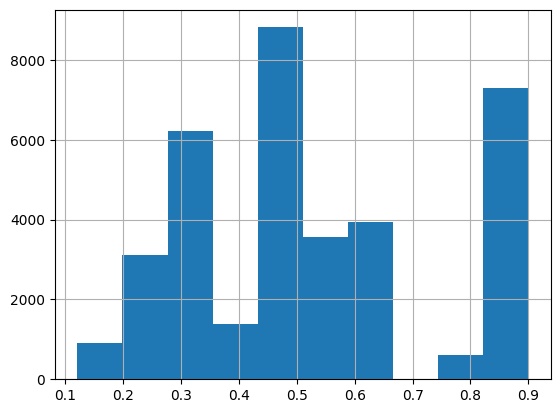

In [60]:
df['score'].hist()

In [61]:
ind = list(set(df['node1_ID'].unique().tolist() + df['node2_ID'].unique().tolist()))
ind.sort()
print(len(ind))
# 9836 unique genes for 35869 SL pairs 

9836


In [62]:
sl = df.copy()

In [63]:
nodes = nodes2id['GENE'].copy()
genes = nodes['GENE_id'].tolist()

In [67]:
sl.loc[:,['node1_type', 'node2_type', 'EdgeDirection']] = ('GENE', 'GENE', 'child-child') 
sl = sl.rename(columns = {'score': 'EdgeScore'})
sl = sl[['node1_ID', 'node1_name', 'node1_type', 'node2_ID', 'node2_name', 'node2_type', 'EdgeType', 'EdgeScore', 'EdgeDirection', 'cell', 'source',
         'node1_identifier', 'node2_identifier']]

In [68]:
sl

,node1_ID,node1_name,node1_type,node2_ID,node2_name,node2_type,EdgeType,EdgeScore,EdgeDirection,cell,source,node1_identifier,node2_identifier
0,ENSG00000126950,TMEM35A,GENE,ENSG00000171862,PTEN,GENE,SL,0.300,child-child,NaN,Computational Prediction,59353,5728
1,ENSG00000126950,TMEM35A,GENE,ENSG00000139618,BRCA2,GENE,SL,0.300,child-child,NaN,Computational Prediction,59353,675
2,ENSG00000176194,CIDEA,GENE,ENSG00000159593,NAE1,GENE,SL,0.500,child-child,A375,GenomeRNAi,1149,8883
3,ENSG00000112214,FHL5,GENE,ENSG00000082556,OPRK1,GENE,SL,0.300,child-child,NaN,Computational Prediction,9457,4986
4,ENSG00000112214,FHL5,GENE,ENSG00000106128,GHRHR,GENE,SL,0.300,child-child,NaN,Computational Prediction,9457,2692
...,...,...,...,...,...,...,...,...,...,...,...,...,...
35864,ENSG00000065675,PRKCQ,GENE,ENSG00000175003,SLC22A1,GENE,SL,0.521,child-child,K562;K562,GenomeRNAi,5588,6580
35865,ENSG00000034677,RNF19A,GENE,ENSG00000141510,TP53,GENE,SL,0.300,child-child,NaN,Computational Prediction,25897,7157
35866,ENSG00000120519,SLC10A7,GENE,ENSG00000149311,ATM,GENE,SL,0.300,child-child,NaN,Computational Prediction,84068,472
35867,ENSG00000197321,SVIL,GENE,ENSG00000171862,PTEN,GENE,SL,0.300,child-child,NaN,Computational Prediction,6840,5728


In [ ]:
sl.to_csv(
    data_processed_path+'humans_SL_35869.tsv',
    header = True, index = False, sep = '\t', mode = 'x'
)

## end